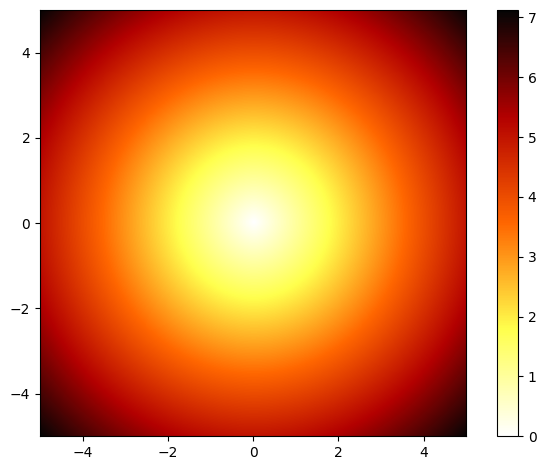

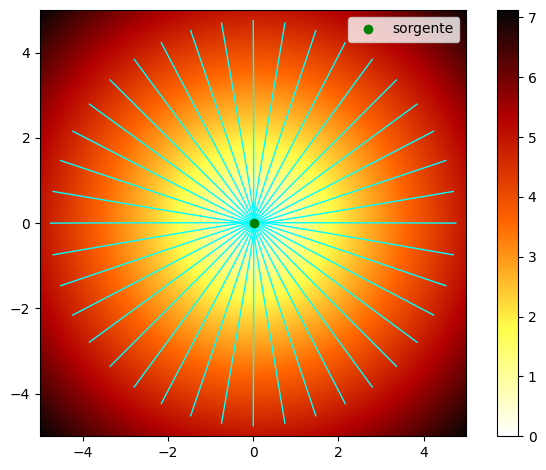

In [ ]:
# ==============================================================================
# --------- VERSIONE FIM PARALLELIZZATA IN RAWKERNEL FASCIO IN SPAZIO LIBERO
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny   = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h = dx

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = np.ones(X.shape, dtype=np.float32)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

ix0, iy0 = 250, 250
T = np.full(X.shape, np.inf, dtype=np.float32)
T[iy0, ix0] = 0.0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True


#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

godunov_kernel_code = r'''
extern "C" __global__
void godunov_update(
    const float* T,        // matrice T corrente (nRows x nCols)
    const float* F,        // campo velocità    (nRows x nCols)
    const int*   rows,     // indici riga  dei nodi attivi
    const int*   cols,     // indici colonna dei nodi attivi
    float*       T_new,    // valori aggiornati (output, stessa dim di rows)
    int          n_active, // numero di nodi attivi
    int          nRows,
    int          nCols,
    float        h
) {
    // indice globale del thread → indice nel vettore dei nodi attivi
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_active) return;

    int r = rows[i];
    int c = cols[i];

    // se il nodo stesso è un muro, non fare nulla
    if (isinf(F[r * nCols + c])) {
        T_new[i] = T[r * nCols + c];
        return;
    }

    // leggi i vicini (usa inf se fuori griglia o muro)
    float left  = (c - 1 >= 0)    ? T[r * nCols + (c-1)] : 1e30f;
    float right = (c + 1 < nCols) ? T[r * nCols + (c+1)] : 1e30f;
    float down  = (r - 1 >= 0)    ? T[(r-1) * nCols + c] : 1e30f;
    float up    = (r + 1 < nRows) ? T[(r+1) * nCols + c] : 1e30f;

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float f   = F[r * nCols + c];
    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[i] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_kernel_code, 'godunov_update')


#------------------  AGGIORNAMENTO FIM  ----------------------------------------

def FIM(T, F, active):

    threads_per_block = 256

    while cp.any(active):

        row, col = cp.where(active)
        n_active = len(row)

        # prepara array di output per i valori aggiornati
        T_new = cp.empty(n_active, dtype=cp.float32)

        # calcolo griglia
        blocchi = (n_active + threads_per_block - 1) // threads_per_block

        # lancia il kernel
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T, F,
             row.astype(cp.int32), col.astype(cp.int32),
             T_new,
             cp.int32(n_active), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        # aggiorna T con i nuovi valori
        p = T[row, col].copy()
        T[row, col] = T_new

        # check convergenza
        converged_cond = cp.abs(p - T_new) < eps
        conv_row = row[converged_cond]
        conv_col = col[converged_cond]
        active[conv_row, conv_col] = False

        # propagazione ai vicini (invariata)
        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # per i vicini usi ancora il kernel
        n_nb = len(nb_row)
        T_nb_new = cp.empty(n_nb, dtype=cp.float32)
        blocchi_nb = (n_nb + threads_per_block - 1) // threads_per_block

        godunov_ker(
            (blocchi_nb,), (threads_per_block,),
            (T, F,
             nb_row.astype(cp.int32), nb_col.astype(cp.int32),
             T_nb_new,
             cp.int32(n_nb), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        improve = T_nb_new < T[nb_row, nb_col]
        nb_row, nb_col = nb_row[improve], nb_col[improve]
        T_nb_new = T_nb_new[improve]

        T[nb_row, nb_col] = T_nb_new
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()



# ==============================================================================
# CALCOLO DEI RAGGI (INTERP.BILINEARE + RK4) IN RAWKERNEL
# ==============================================================================

#------------------  KERNEL GRADIENTE (RAWKERNEL) ------------------------------

gradient_kernel_code = r'''
extern "C" __global__
void gradient_fd(
    const float* T,       // campo T (nRows x nCols)
    const float* F,       // campo velocità (nRows x nCols)
    float*       Tx,      // output gradiente x
    float*       Ty,      // output gradiente y
    int          nRows,
    int          nCols,
    float        dx,
    float        dy
) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row >= nRows || col >= nCols) return;

    int idx = row * nCols + col;

    bool wall_here = isinf(F[idx]);
    if (wall_here) {
        Tx[idx] = 0.0f;
        Ty[idx] = 0.0f;
        return;
    }

    // ---- derivata rispetto a x ----
    bool left_ok  = (col - 1 >= 0)    && !isinf(F[row*nCols + (col-1)]);
    bool right_ok = (col + 1 < nCols) && !isinf(F[row*nCols + (col+1)]);

    float tx_val = 0.0f;
    if (left_ok && right_ok) {
        float t_left  = T[row*nCols + (col-1)];
        float t_right = T[row*nCols + (col+1)];
        tx_val = (t_right - t_left) / (2.0f * dx);
    } else if (right_ok && !left_ok) {
        float t_right = T[row*nCols + (col+1)];
        tx_val = (t_right - T[idx]) / dx;
    } else if (left_ok && !right_ok) {
        float t_left = T[row*nCols + (col-1)];
        tx_val = (T[idx] - t_left) / dx;
    }
    // altrimenti (entrambi muro/bordo) resta 0

    // ---- derivata rispetto a y ----
    bool down_ok = (row - 1 >= 0)    && !isinf(F[(row-1)*nCols + col]);
    bool up_ok   = (row + 1 < nRows) && !isinf(F[(row+1)*nCols + col]);

    float ty_val = 0.0f;
    if (down_ok && up_ok) {
        float t_down = T[(row-1)*nCols + col];
        float t_up   = T[(row+1)*nCols + col];
        ty_val = (t_up - t_down) / (2.0f * dy);
    } else if (up_ok && !down_ok) {
        float t_up = T[(row+1)*nCols + col];
        ty_val = (t_up - T[idx]) / dy;
    } else if (down_ok && !up_ok) {
        float t_down = T[(row-1)*nCols + col];
        ty_val = (T[idx] - t_down) / dy;
    }

    // ---- rinormalizzazione secondo l'eikonale: |grad T| = 1/F ----
    float grad_norm = sqrtf(tx_val*tx_val + ty_val*ty_val);
    float f = F[idx];

    if (isfinite(f) && grad_norm > 1e-12f) {
        float scale = 1.0f / (f * grad_norm);
        Tx[idx] = tx_val * scale;
        Ty[idx] = ty_val * scale;
    } else {
        Tx[idx] = 0.0f;
        Ty[idx] = 0.0f;
    }
}
'''

gradient_ker = cp.RawKernel(gradient_kernel_code, 'gradient_fd')


#------------------  LANCIO KERNEL GRADIENTE -------------------------------------

Tx_gpu_raw = cp.zeros((nRows, nCols), dtype=cp.float32)
Ty_gpu_raw = cp.zeros((nRows, nCols), dtype=cp.float32)

threads_2d = (16, 16)
blocks_2d = (
    (nCols + threads_2d[0] - 1) // threads_2d[0],
    (nRows + threads_2d[1] - 1) // threads_2d[1],
)

gradient_ker(
    blocks_2d, threads_2d,
    (T_final_gpu, F_gpu,
     Tx_gpu_raw, Ty_gpu_raw,
     cp.int32(nRows), cp.int32(nCols),
     cp.float32(dx), cp.float32(dy))
)


#------------------  RIEMPIMENTO MURI (fill_wall_nans) --------------------------

wall_mask_cpu = np.isinf(cp.asnumpy(F_gpu))
Tx_cpu = cp.asnumpy(Tx_gpu_raw)
Ty_cpu = cp.asnumpy(Ty_gpu_raw)

idx = distance_transform_edt(wall_mask_cpu, return_distances=False, return_indices=True)
Tx_filled_cpu = Tx_cpu[tuple(idx)]
Ty_filled_cpu = Ty_cpu[tuple(idx)]

Tx_filled = cp.array(Tx_filled_cpu, dtype=cp.float32)
Ty_filled = cp.array(Ty_filled_cpu, dtype=cp.float32)
#------------------  UPLOAD GRADIENTI SU GPU -----------------------------------

Tx_gpu = cp.array(Tx_filled, dtype=cp.float32)
Ty_gpu = cp.array(Ty_filled, dtype=cp.float32)
x_gpu  = cp.array(x, dtype=cp.float32)
y_gpu  = cp.array(y, dtype=cp.float32)

#------------------  KERNEL RAY TRACING (RK4 + BILINEARE) ----------------------

raytrace_kernel_code = r'''
extern "C" __global__
void trace_rays(
    const float* Tx,        // gradiente x  (nRows x nCols)
    const float* Ty,        // gradiente y  (nRows x nCols)
    const float* xg,        // coordinate griglia x (nCols)
    const float* yg,        // coordinate griglia y (nRows)
    const float* start_x,   // punti di partenza x  (n_rays)
    const float* start_y,   // punti di partenza y  (n_rays)
    float*       out_x,     // traiettoria x  (n_rays x (max_steps+1))
    float*       out_y,     // traiettoria y  (n_rays x (max_steps+1))
    int*         out_len,   // numero di punti effettivi scritti per raggio
    int          n_rays,
    int          nRows,
    int          nCols,
    float        x0, float y0,     // origine griglia
    float        dx, float dy,
    float        ds,
    int           max_steps,
    float        sx, float sy      // punto sorgente
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_rays) return;

    // ---------- bilinear interp device inline (di un singolo campo) ----------
    // definita qui sotto come lambda-macro tramite funzione device separata

    float px = start_x[i];
    float py = start_y[i];

    int base = i * (max_steps + 1);
    out_x[base] = px;
    out_y[base] = py;
    int n_written = 1;

    for (int step = 0; step < max_steps; step++) {

        float k1x, k1y, k2x, k2y, k3x, k3y, k4x, k4y;

        // ---- k1 ----
        {
            float cpx = fminf(fmaxf(px, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(py, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k1x = -gx; k1y = -gy;
        }

        if (fabsf(k1x) < 1e-12f && fabsf(k1y) < 1e-12f) break;

        // ---- k2 ----
        {
            float qx = px + 0.5f*ds*k1x;
            float qy = py + 0.5f*ds*k1y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k2x = -gx; k2y = -gy;
        }

        // ---- k3 ----
        {
            float qx = px + 0.5f*ds*k2x;
            float qy = py + 0.5f*ds*k2y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k3x = -gx; k3y = -gy;
        }

        // ---- k4 ----
        {
            float qx = px + ds*k3x;
            float qy = py + ds*k3y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k4x = -gx; k4y = -gy;
        }

        float dpx = (k1x + 2.0f*k2x + 2.0f*k3x + k4x) / 6.0f;
        float dpy = (k1y + 2.0f*k2y + 2.0f*k3y + k4y) / 6.0f;

        float px_new = px + ds*dpx;
        float py_new = py + ds*dpy;

        out_x[base + n_written] = px_new;
        out_y[base + n_written] = py_new;
        n_written++;

        float dsrc = sqrtf((px_new-sx)*(px_new-sx) + (py_new-sy)*(py_new-sy));
        if (dsrc < ds) {
            out_x[base + n_written] = sx;
            out_y[base + n_written] = sy;
            n_written++;
            break;
        }

        float disp = sqrtf((px_new-px)*(px_new-px) + (py_new-py)*(py_new-py));
        if (disp < 1e-8f) break;

        px = px_new;
        py = py_new;
    }

    out_len[i] = n_written;
}
'''

raytrace_ker = cp.RawKernel(raytrace_kernel_code, 'trace_rays')


#------------------  LANCIO DEL FASCIO -------------------------------------------

n_rays = 40
R_exit = sidex * 0.95
angles = np.linspace(0, 2*np.pi, n_rays, endpoint=False)

start_x = (R_exit*np.cos(angles)).astype(np.float32)
start_y = (R_exit*np.sin(angles)).astype(np.float32)
source_pt = (float(x[ix0]), float(y[iy0]))

ds = np.float32(dx/2)
max_steps = 10000
nCols, nRows = X.shape[1], X.shape[0]

start_x_gpu = cp.array(start_x)
start_y_gpu = cp.array(start_y)

out_x_gpu = cp.zeros(n_rays * (max_steps + 1), dtype=cp.float32)
out_y_gpu = cp.zeros(n_rays * (max_steps + 1), dtype=cp.float32)
out_len_gpu = cp.zeros(n_rays, dtype=cp.int32)

threads_per_block = 32
blocchi = (n_rays + threads_per_block - 1) // threads_per_block

raytrace_ker(
    (blocchi,), (threads_per_block,),
    (Tx_gpu, Ty_gpu, x_gpu, y_gpu,
     start_x_gpu, start_y_gpu,
     out_x_gpu, out_y_gpu, out_len_gpu,
     cp.int32(n_rays), cp.int32(nRows), cp.int32(nCols),
     cp.float32(x[0]), cp.float32(y[0]),
     cp.float32(dx), cp.float32(dy),
     ds, cp.int32(max_steps),
     cp.float32(source_pt[0]), cp.float32(source_pt[1]))
)

# torna su CPU e ricostruisci i singoli raggi usando out_len
out_x = cp.asnumpy(out_x_gpu).reshape(n_rays, max_steps + 1)
out_y = cp.asnumpy(out_y_gpu).reshape(n_rays, max_steps + 1)
out_len = cp.asnumpy(out_len_gpu)

rays_fan = [np.stack([out_x[i, :out_len[i]], out_y[i, :out_len[i]]], axis=1)
            for i in range(n_rays)]

#------------------  PLOT ---------------------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)
for ray in rays_fan:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)
ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()

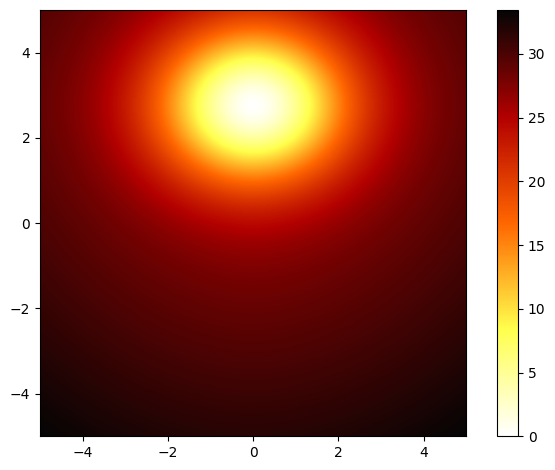

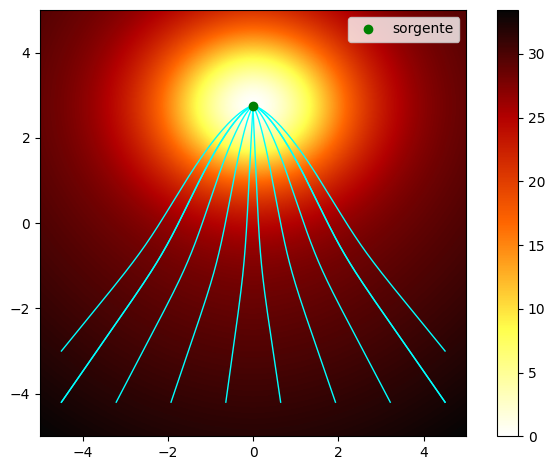

In [ ]:
# ==============================================================================
# --------- VERSIONE FIM PARALLELIZZATA IN RAWKERNEL FASCIO SU MONTAGNA
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny   = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h = dx

#------------------  CAMPO DI VELOCITA' (MONTAGNA) -----------------------------

# Elevazione sintetica: una "montagna" gaussiana posta nella parte alta del dominio
cx, cy   = 0.0, sidey * 0.55      # centro della montagna (alto, y>0)
sigma_x, sigma_y = 1.6, 1.3
altezza  = 3.0

Z = altezza * np.exp(-(((X - cx)**2) / (2*sigma_x**2) +
                       ((Y - cy)**2) / (2*sigma_y**2)))

# Pendenza locale (norma del gradiente dell'elevazione)
gz_y, gz_x = np.gradient(Z, dy, dx)
slope = np.sqrt(gz_x**2 + gz_y**2)

# F alto (veloce) dove il terreno è pianeggiante/valle, F basso dove è ripido/vetta
k_slope = 8.0
F = (1.0 / (1.0 + k_slope * slope)).astype(np.float32)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE (VETTA DELLA MONTAGNA) ---------------------------

iy0, ix0 = np.unravel_index(np.argmax(Z), Z.shape)   # nodo di elevazione massima
T = np.full(X.shape, np.inf, dtype=np.float32)
T[iy0, ix0] = 0.0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

godunov_kernel_code = r'''
extern "C" __global__
void godunov_update(
    const float* T,        // matrice T corrente (nRows x nCols)
    const float* F,        // campo velocità    (nRows x nCols)
    const int*   rows,     // indici riga  dei nodi attivi
    const int*   cols,     // indici colonna dei nodi attivi
    float*       T_new,    // valori aggiornati (output, stessa dim di rows)
    int          n_active, // numero di nodi attivi
    int          nRows,
    int          nCols,
    float        h
) {
    // indice globale del thread → indice nel vettore dei nodi attivi
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_active) return;

    int r = rows[i];
    int c = cols[i];

    // se il nodo stesso è un muro, non fare nulla
    if (isinf(F[r * nCols + c])) {
        T_new[i] = T[r * nCols + c];
        return;
    }

    // leggi i vicini (usa inf se fuori griglia o muro)
    float left  = (c - 1 >= 0)    ? T[r * nCols + (c-1)] : 1e30f;
    float right = (c + 1 < nCols) ? T[r * nCols + (c+1)] : 1e30f;
    float down  = (r - 1 >= 0)    ? T[(r-1) * nCols + c] : 1e30f;
    float up    = (r + 1 < nRows) ? T[(r+1) * nCols + c] : 1e30f;

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float f   = F[r * nCols + c];
    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[i] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_kernel_code, 'godunov_update')


#------------------  AGGIORNAMENTO FIM  ----------------------------------------

def FIM(T, F, active):

    threads_per_block = 256

    while cp.any(active):

        row, col = cp.where(active)
        n_active = len(row)

        # prepara array di output per i valori aggiornati
        T_new = cp.empty(n_active, dtype=cp.float32)

        # calcolo griglia
        blocchi = (n_active + threads_per_block - 1) // threads_per_block

        # lancia il kernel
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T, F,
             row.astype(cp.int32), col.astype(cp.int32),
             T_new,
             cp.int32(n_active), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        # aggiorna T con i nuovi valori
        p = T[row, col].copy()
        T[row, col] = T_new

        # check convergenza
        converged_cond = cp.abs(p - T_new) < eps
        conv_row = row[converged_cond]
        conv_col = col[converged_cond]
        active[conv_row, conv_col] = False

        # propagazione ai vicini (invariata)
        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # per i vicini usi ancora il kernel
        n_nb = len(nb_row)
        T_nb_new = cp.empty(n_nb, dtype=cp.float32)
        blocchi_nb = (n_nb + threads_per_block - 1) // threads_per_block

        godunov_ker(
            (blocchi_nb,), (threads_per_block,),
            (T, F,
             nb_row.astype(cp.int32), nb_col.astype(cp.int32),
             T_nb_new,
             cp.int32(n_nb), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        improve = T_nb_new < T[nb_row, nb_col]
        nb_row, nb_col = nb_row[improve], nb_col[improve]
        T_nb_new = T_nb_new[improve]

        T[nb_row, nb_col] = T_nb_new
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()



# ==============================================================================
# CALCOLO DEI RAGGI (INTERP.BILINEARE + RK4) IN RAWKERNEL
# ==============================================================================

#------------------  KERNEL GRADIENTE (RAWKERNEL) ------------------------------

gradient_kernel_code = r'''
extern "C" __global__
void gradient_fd(
    const float* T,       // campo T (nRows x nCols)
    const float* F,       // campo velocità (nRows x nCols)
    float*       Tx,      // output gradiente x
    float*       Ty,      // output gradiente y
    int          nRows,
    int          nCols,
    float        dx,
    float        dy
) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row >= nRows || col >= nCols) return;

    int idx = row * nCols + col;

    bool wall_here = isinf(F[idx]);
    if (wall_here) {
        Tx[idx] = 0.0f;
        Ty[idx] = 0.0f;
        return;
    }

    // ---- derivata rispetto a x ----
    bool left_ok  = (col - 1 >= 0)    && !isinf(F[row*nCols + (col-1)]);
    bool right_ok = (col + 1 < nCols) && !isinf(F[row*nCols + (col+1)]);

    float tx_val = 0.0f;
    if (left_ok && right_ok) {
        float t_left  = T[row*nCols + (col-1)];
        float t_right = T[row*nCols + (col+1)];
        tx_val = (t_right - t_left) / (2.0f * dx);
    } else if (right_ok && !left_ok) {
        float t_right = T[row*nCols + (col+1)];
        tx_val = (t_right - T[idx]) / dx;
    } else if (left_ok && !right_ok) {
        float t_left = T[row*nCols + (col-1)];
        tx_val = (T[idx] - t_left) / dx;
    }
    // altrimenti (entrambi muro/bordo) resta 0

    // ---- derivata rispetto a y ----
    bool down_ok = (row - 1 >= 0)    && !isinf(F[(row-1)*nCols + col]);
    bool up_ok   = (row + 1 < nRows) && !isinf(F[(row+1)*nCols + col]);

    float ty_val = 0.0f;
    if (down_ok && up_ok) {
        float t_down = T[(row-1)*nCols + col];
        float t_up   = T[(row+1)*nCols + col];
        ty_val = (t_up - t_down) / (2.0f * dy);
    } else if (up_ok && !down_ok) {
        float t_up = T[(row+1)*nCols + col];
        ty_val = (t_up - T[idx]) / dy;
    } else if (down_ok && !up_ok) {
        float t_down = T[(row-1)*nCols + col];
        ty_val = (T[idx] - t_down) / dy;
    }

    // ---- rinormalizzazione secondo l'eikonale: |grad T| = 1/F ----
    float grad_norm = sqrtf(tx_val*tx_val + ty_val*ty_val);
    float f = F[idx];

    if (isfinite(f) && grad_norm > 1e-12f) {
        float scale = 1.0f / (f * grad_norm);
        Tx[idx] = tx_val * scale;
        Ty[idx] = ty_val * scale;
    } else {
        Tx[idx] = 0.0f;
        Ty[idx] = 0.0f;
    }
}
'''

gradient_ker = cp.RawKernel(gradient_kernel_code, 'gradient_fd')


#------------------  LANCIO KERNEL GRADIENTE -------------------------------------

Tx_gpu_raw = cp.zeros((nRows, nCols), dtype=cp.float32)
Ty_gpu_raw = cp.zeros((nRows, nCols), dtype=cp.float32)

threads_2d = (16, 16)
blocks_2d = (
    (nCols + threads_2d[0] - 1) // threads_2d[0],
    (nRows + threads_2d[1] - 1) // threads_2d[1],
)

gradient_ker(
    blocks_2d, threads_2d,
    (T_final_gpu, F_gpu,
     Tx_gpu_raw, Ty_gpu_raw,
     cp.int32(nRows), cp.int32(nCols),
     cp.float32(dx), cp.float32(dy))
)


#------------------  RIEMPIMENTO MURI (fill_wall_nans) --------------------------

wall_mask_cpu = np.isinf(cp.asnumpy(F_gpu))
Tx_cpu = cp.asnumpy(Tx_gpu_raw)
Ty_cpu = cp.asnumpy(Ty_gpu_raw)

idx = distance_transform_edt(wall_mask_cpu, return_distances=False, return_indices=True)
Tx_filled_cpu = Tx_cpu[tuple(idx)]
Ty_filled_cpu = Ty_cpu[tuple(idx)]

Tx_filled = cp.array(Tx_filled_cpu, dtype=cp.float32)
Ty_filled = cp.array(Ty_filled_cpu, dtype=cp.float32)
#------------------  UPLOAD GRADIENTI SU GPU -----------------------------------

Tx_gpu = cp.array(Tx_filled, dtype=cp.float32)
Ty_gpu = cp.array(Ty_filled, dtype=cp.float32)
x_gpu  = cp.array(x, dtype=cp.float32)
y_gpu  = cp.array(y, dtype=cp.float32)

#------------------  KERNEL RAY TRACING (RK4 + BILINEARE) ----------------------

raytrace_kernel_code = r'''
extern "C" __global__
void trace_rays(
    const float* Tx,        // gradiente x  (nRows x nCols)
    const float* Ty,        // gradiente y  (nRows x nCols)
    const float* xg,        // coordinate griglia x (nCols)
    const float* yg,        // coordinate griglia y (nRows)
    const float* start_x,   // punti di partenza x  (n_rays)
    const float* start_y,   // punti di partenza y  (n_rays)
    float*       out_x,     // traiettoria x  (n_rays x (max_steps+1))
    float*       out_y,     // traiettoria y  (n_rays x (max_steps+1))
    int*         out_len,   // numero di punti effettivi scritti per raggio
    int          n_rays,
    int          nRows,
    int          nCols,
    float        x0, float y0,     // origine griglia
    float        dx, float dy,
    float        ds,
    int           max_steps,
    float        sx, float sy      // punto sorgente
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_rays) return;

    // ---------- bilinear interp device inline (di un singolo campo) ----------
    // definita qui sotto come lambda-macro tramite funzione device separata

    float px = start_x[i];
    float py = start_y[i];

    int base = i * (max_steps + 1);
    out_x[base] = px;
    out_y[base] = py;
    int n_written = 1;

    for (int step = 0; step < max_steps; step++) {

        float k1x, k1y, k2x, k2y, k3x, k3y, k4x, k4y;

        // ---- k1 ----
        {
            float cpx = fminf(fmaxf(px, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(py, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k1x = -gx; k1y = -gy;
        }

        if (fabsf(k1x) < 1e-12f && fabsf(k1y) < 1e-12f) break;

        // ---- k2 ----
        {
            float qx = px + 0.5f*ds*k1x;
            float qy = py + 0.5f*ds*k1y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k2x = -gx; k2y = -gy;
        }

        // ---- k3 ----
        {
            float qx = px + 0.5f*ds*k2x;
            float qy = py + 0.5f*ds*k2y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k3x = -gx; k3y = -gy;
        }

        // ---- k4 ----
        {
            float qx = px + ds*k3x;
            float qy = py + ds*k3y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k4x = -gx; k4y = -gy;
        }

        float dpx = (k1x + 2.0f*k2x + 2.0f*k3x + k4x) / 6.0f;
        float dpy = (k1y + 2.0f*k2y + 2.0f*k3y + k4y) / 6.0f;

        float px_new = px + ds*dpx;
        float py_new = py + ds*dpy;

        out_x[base + n_written] = px_new;
        out_y[base + n_written] = py_new;
        n_written++;

        float dsrc = sqrtf((px_new-sx)*(px_new-sx) + (py_new-sy)*(py_new-sy));
        if (dsrc < ds) {
            out_x[base + n_written] = sx;
            out_y[base + n_written] = sy;
            n_written++;
            break;
        }

        float disp = sqrtf((px_new-px)*(px_new-px) + (py_new-py)*(py_new-py));
        if (disp < 1e-8f) break;

        px = px_new;
        py = py_new;
    }

    out_len[i] = n_written;
}
'''

raytrace_ker = cp.RawKernel(raytrace_kernel_code, 'trace_rays')



#------------------  LANCIO DEL FASCIO (PARTENZA DA VALLE + LATI BASSI) --------

n_bottom = 8
n_side   = 2   # per lato (sinistro e destro)

y_top_side = domain[2] + 0.2 * (domain[3] - domain[2])   # fin dove salire sui lati (resta sotto la montagna)
y_valley   = domain[2] + 0.08 * (domain[3] - domain[2])

# bordo inferiore
x_bottom = np.linspace(-sidex*0.9, sidex*0.9, n_bottom).astype(np.float32)
y_bottom = np.full(n_bottom, y_valley, dtype=np.float32)

# lato sinistro (dal basso fino a y_top_side)
x_left = np.full(n_side, domain[0] + 0.05*(domain[1]-domain[0]), dtype=np.float32)
y_left = np.linspace(y_valley, y_top_side, n_side).astype(np.float32)

# lato destro
x_right = np.full(n_side, domain[1] - 0.05*(domain[1]-domain[0]), dtype=np.float32)
y_right = np.linspace(y_valley, y_top_side, n_side).astype(np.float32)

start_x = np.concatenate([x_bottom, x_left, x_right])
start_y = np.concatenate([y_bottom, y_left, y_right])
n_rays  = len(start_x)

source_pt = (float(x[ix0]), float(y[iy0]))

ds = np.float32(dx/2)
max_steps = 10000
nCols, nRows = X.shape[1], X.shape[0]

start_x_gpu = cp.array(start_x)
start_y_gpu = cp.array(start_y)

out_x_gpu = cp.zeros(n_rays * (max_steps + 1), dtype=cp.float32)
out_y_gpu = cp.zeros(n_rays * (max_steps + 1), dtype=cp.float32)
out_len_gpu = cp.zeros(n_rays, dtype=cp.int32)

threads_per_block = 32
blocchi = (n_rays + threads_per_block - 1) // threads_per_block

raytrace_ker(
    (blocchi,), (threads_per_block,),
    (Tx_gpu, Ty_gpu, x_gpu, y_gpu,
     start_x_gpu, start_y_gpu,
     out_x_gpu, out_y_gpu, out_len_gpu,
     cp.int32(n_rays), cp.int32(nRows), cp.int32(nCols),
     cp.float32(x[0]), cp.float32(y[0]),
     cp.float32(dx), cp.float32(dy),
     ds, cp.int32(max_steps),
     cp.float32(source_pt[0]), cp.float32(source_pt[1]))
)

# torna su CPU e ricostruisci i singoli raggi usando out_len
out_x = cp.asnumpy(out_x_gpu).reshape(n_rays, max_steps + 1)
out_y = cp.asnumpy(out_y_gpu).reshape(n_rays, max_steps + 1)
out_len = cp.asnumpy(out_len_gpu)

rays_fan = [np.stack([out_x[i, :out_len[i]], out_y[i, :out_len[i]]], axis=1)
            for i in range(n_rays)]

#------------------  PLOT ---------------------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)
for ray in rays_fan:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)
ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()

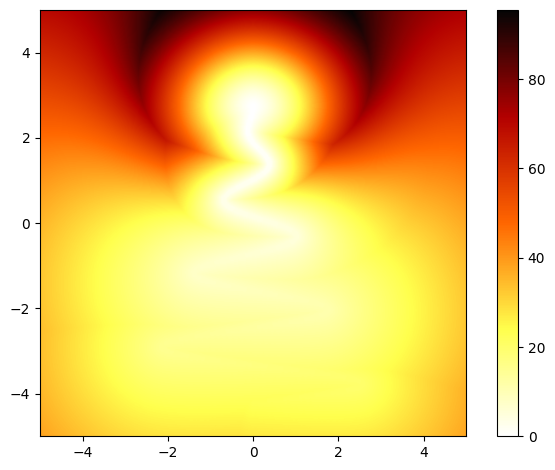

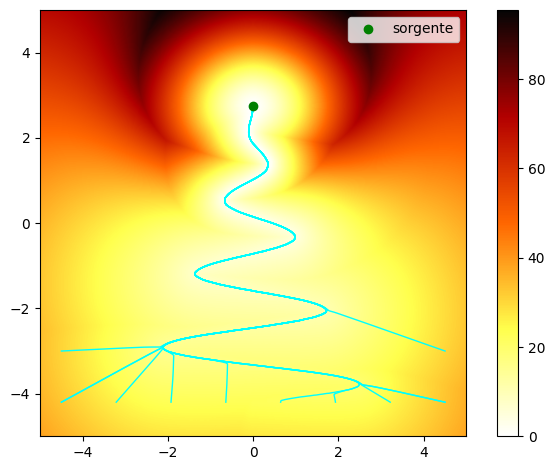

In [ ]:
# ==============================================================================
# --------- VERSIONE FIM PARALLELIZZATA IN RAWKERNEL FASCIO SU PERCORSO DI MONTAGNA
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny   = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h = dx

#------------------  CAMPO DI VELOCITA' (MONTAGNA + STRADA A TORNANTI) ---------

cx, cy   = 0.0, sidey * 0.55
sigma_x, sigma_y = 1.6, 1.3
altezza  = 3.0

Z = altezza * np.exp(-(((X - cx)**2) / (2*sigma_x**2) +
                       ((Y - cy)**2) / (2*sigma_y**2)))

gz_y, gz_x = np.gradient(Z, dy, dx)
slope = np.sqrt(gz_x**2 + gz_y**2)

k_slope  = 4.0
F_slope  = 1.0 / (1.0 + k_slope * slope)

# --------- Strada a tornanti (curva a S che sale verso la vetta) ---------

n_pts       = 4000
t           = np.linspace(0.0, 1.0, n_pts)

y_valley    = domain[2] + 0.08 * (domain[3] - domain[2])
road_y      = y_valley + t * (cy - y_valley)          # sale dalla valle fino alla vetta

n_tornanti  = 4                                       # numero di "S" lungo la salita
ampiezza    = sidex * 0.55 * (1 - t)**1.2             # si restringe salendo (converge alla vetta)
road_x      = ampiezza * np.sin(2*np.pi*n_tornanti*t)

col_idx = np.clip(((road_x - domain[0]) / dx).astype(int), 0, nCols-1)
row_idx = np.clip(((road_y - domain[2]) / dy).astype(int), 0, nRows-1)

road_mask = np.zeros((nRows, nCols), dtype=bool)
road_mask[row_idx, col_idx] = True

from scipy.ndimage import binary_dilation
road_width = 2                                        # semi-larghezza della strada, in celle
road_mask = binary_dilation(road_mask, iterations=road_width)

# --------- F finale: strada veloce, fuori strada penalizzato dalla pendenza ---------

penalita_fuoristrada = 0.15    # <1 per rendere la strada nettamente preferibile
F = np.where(road_mask, 1.0, F_slope * penalita_fuoristrada).astype(np.float32)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE (VETTA DELLA MONTAGNA) ---------------------------

iy0, ix0 = np.unravel_index(np.argmax(Z), Z.shape)   # nodo di elevazione massima
T = np.full(X.shape, np.inf, dtype=np.float32)
T[iy0, ix0] = 0.0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

godunov_kernel_code = r'''
extern "C" __global__
void godunov_update(
    const float* T,        // matrice T corrente (nRows x nCols)
    const float* F,        // campo velocità    (nRows x nCols)
    const int*   rows,     // indici riga  dei nodi attivi
    const int*   cols,     // indici colonna dei nodi attivi
    float*       T_new,    // valori aggiornati (output, stessa dim di rows)
    int          n_active, // numero di nodi attivi
    int          nRows,
    int          nCols,
    float        h
) {
    // indice globale del thread → indice nel vettore dei nodi attivi
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_active) return;

    int r = rows[i];
    int c = cols[i];

    // se il nodo stesso è un muro, non fare nulla
    if (isinf(F[r * nCols + c])) {
        T_new[i] = T[r * nCols + c];
        return;
    }

    // leggi i vicini (usa inf se fuori griglia o muro)
    float left  = (c - 1 >= 0)    ? T[r * nCols + (c-1)] : 1e30f;
    float right = (c + 1 < nCols) ? T[r * nCols + (c+1)] : 1e30f;
    float down  = (r - 1 >= 0)    ? T[(r-1) * nCols + c] : 1e30f;
    float up    = (r + 1 < nRows) ? T[(r+1) * nCols + c] : 1e30f;

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float f   = F[r * nCols + c];
    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[i] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_kernel_code, 'godunov_update')


#------------------  AGGIORNAMENTO FIM  ----------------------------------------

def FIM(T, F, active):

    threads_per_block = 256

    while cp.any(active):

        row, col = cp.where(active)
        n_active = len(row)

        # prepara array di output per i valori aggiornati
        T_new = cp.empty(n_active, dtype=cp.float32)

        # calcolo griglia
        blocchi = (n_active + threads_per_block - 1) // threads_per_block

        # lancia il kernel
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T, F,
             row.astype(cp.int32), col.astype(cp.int32),
             T_new,
             cp.int32(n_active), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        # aggiorna T con i nuovi valori
        p = T[row, col].copy()
        T[row, col] = T_new

        # check convergenza
        converged_cond = cp.abs(p - T_new) < eps
        conv_row = row[converged_cond]
        conv_col = col[converged_cond]
        active[conv_row, conv_col] = False

        # propagazione ai vicini (invariata)
        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # per i vicini usi ancora il kernel
        n_nb = len(nb_row)
        T_nb_new = cp.empty(n_nb, dtype=cp.float32)
        blocchi_nb = (n_nb + threads_per_block - 1) // threads_per_block

        godunov_ker(
            (blocchi_nb,), (threads_per_block,),
            (T, F,
             nb_row.astype(cp.int32), nb_col.astype(cp.int32),
             T_nb_new,
             cp.int32(n_nb), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        improve = T_nb_new < T[nb_row, nb_col]
        nb_row, nb_col = nb_row[improve], nb_col[improve]
        T_nb_new = T_nb_new[improve]

        T[nb_row, nb_col] = T_nb_new
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()



# ==============================================================================
# CALCOLO DEI RAGGI (INTERP.BILINEARE + RK4) IN RAWKERNEL
# ==============================================================================

#------------------  KERNEL GRADIENTE (RAWKERNEL) ------------------------------

gradient_kernel_code = r'''
extern "C" __global__
void gradient_fd(
    const float* T,       // campo T (nRows x nCols)
    const float* F,       // campo velocità (nRows x nCols)
    float*       Tx,      // output gradiente x
    float*       Ty,      // output gradiente y
    int          nRows,
    int          nCols,
    float        dx,
    float        dy
) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row >= nRows || col >= nCols) return;

    int idx = row * nCols + col;

    bool wall_here = isinf(F[idx]);
    if (wall_here) {
        Tx[idx] = 0.0f;
        Ty[idx] = 0.0f;
        return;
    }

    // ---- derivata rispetto a x ----
    bool left_ok  = (col - 1 >= 0)    && !isinf(F[row*nCols + (col-1)]);
    bool right_ok = (col + 1 < nCols) && !isinf(F[row*nCols + (col+1)]);

    float tx_val = 0.0f;
    if (left_ok && right_ok) {
        float t_left  = T[row*nCols + (col-1)];
        float t_right = T[row*nCols + (col+1)];
        tx_val = (t_right - t_left) / (2.0f * dx);
    } else if (right_ok && !left_ok) {
        float t_right = T[row*nCols + (col+1)];
        tx_val = (t_right - T[idx]) / dx;
    } else if (left_ok && !right_ok) {
        float t_left = T[row*nCols + (col-1)];
        tx_val = (T[idx] - t_left) / dx;
    }
    // altrimenti (entrambi muro/bordo) resta 0

    // ---- derivata rispetto a y ----
    bool down_ok = (row - 1 >= 0)    && !isinf(F[(row-1)*nCols + col]);
    bool up_ok   = (row + 1 < nRows) && !isinf(F[(row+1)*nCols + col]);

    float ty_val = 0.0f;
    if (down_ok && up_ok) {
        float t_down = T[(row-1)*nCols + col];
        float t_up   = T[(row+1)*nCols + col];
        ty_val = (t_up - t_down) / (2.0f * dy);
    } else if (up_ok && !down_ok) {
        float t_up = T[(row+1)*nCols + col];
        ty_val = (t_up - T[idx]) / dy;
    } else if (down_ok && !up_ok) {
        float t_down = T[(row-1)*nCols + col];
        ty_val = (T[idx] - t_down) / dy;
    }

    // ---- rinormalizzazione secondo l'eikonale: |grad T| = 1/F ----
    float grad_norm = sqrtf(tx_val*tx_val + ty_val*ty_val);
    float f = F[idx];

    if (isfinite(f) && grad_norm > 1e-12f) {
        float scale = 1.0f / (f * grad_norm);
        Tx[idx] = tx_val * scale;
        Ty[idx] = ty_val * scale;
    } else {
        Tx[idx] = 0.0f;
        Ty[idx] = 0.0f;
    }
}
'''

gradient_ker = cp.RawKernel(gradient_kernel_code, 'gradient_fd')


#------------------  LANCIO KERNEL GRADIENTE -------------------------------------

Tx_gpu_raw = cp.zeros((nRows, nCols), dtype=cp.float32)
Ty_gpu_raw = cp.zeros((nRows, nCols), dtype=cp.float32)

threads_2d = (16, 16)
blocks_2d = (
    (nCols + threads_2d[0] - 1) // threads_2d[0],
    (nRows + threads_2d[1] - 1) // threads_2d[1],
)

gradient_ker(
    blocks_2d, threads_2d,
    (T_final_gpu, F_gpu,
     Tx_gpu_raw, Ty_gpu_raw,
     cp.int32(nRows), cp.int32(nCols),
     cp.float32(dx), cp.float32(dy))
)


#------------------  RIEMPIMENTO MURI (fill_wall_nans) --------------------------

wall_mask_cpu = np.isinf(cp.asnumpy(F_gpu))
Tx_cpu = cp.asnumpy(Tx_gpu_raw)
Ty_cpu = cp.asnumpy(Ty_gpu_raw)

idx = distance_transform_edt(wall_mask_cpu, return_distances=False, return_indices=True)
Tx_filled_cpu = Tx_cpu[tuple(idx)]
Ty_filled_cpu = Ty_cpu[tuple(idx)]

Tx_filled = cp.array(Tx_filled_cpu, dtype=cp.float32)
Ty_filled = cp.array(Ty_filled_cpu, dtype=cp.float32)
#------------------  UPLOAD GRADIENTI SU GPU -----------------------------------

Tx_gpu = cp.array(Tx_filled, dtype=cp.float32)
Ty_gpu = cp.array(Ty_filled, dtype=cp.float32)
x_gpu  = cp.array(x, dtype=cp.float32)
y_gpu  = cp.array(y, dtype=cp.float32)

#------------------  KERNEL RAY TRACING (RK4 + BILINEARE) ----------------------

raytrace_kernel_code = r'''
extern "C" __global__
void trace_rays(
    const float* Tx,        // gradiente x  (nRows x nCols)
    const float* Ty,        // gradiente y  (nRows x nCols)
    const float* xg,        // coordinate griglia x (nCols)
    const float* yg,        // coordinate griglia y (nRows)
    const float* start_x,   // punti di partenza x  (n_rays)
    const float* start_y,   // punti di partenza y  (n_rays)
    float*       out_x,     // traiettoria x  (n_rays x (max_steps+1))
    float*       out_y,     // traiettoria y  (n_rays x (max_steps+1))
    int*         out_len,   // numero di punti effettivi scritti per raggio
    int          n_rays,
    int          nRows,
    int          nCols,
    float        x0, float y0,     // origine griglia
    float        dx, float dy,
    float        ds,
    int           max_steps,
    float        sx, float sy      // punto sorgente
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_rays) return;

    // ---------- bilinear interp device inline (di un singolo campo) ----------
    // definita qui sotto come lambda-macro tramite funzione device separata

    float px = start_x[i];
    float py = start_y[i];

    int base = i * (max_steps + 1);
    out_x[base] = px;
    out_y[base] = py;
    int n_written = 1;

    for (int step = 0; step < max_steps; step++) {

        float k1x, k1y, k2x, k2y, k3x, k3y, k4x, k4y;

        // ---- k1 ----
        {
            float cpx = fminf(fmaxf(px, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(py, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k1x = -gx; k1y = -gy;
        }

        if (fabsf(k1x) < 1e-12f && fabsf(k1y) < 1e-12f) break;

        // ---- k2 ----
        {
            float qx = px + 0.5f*ds*k1x;
            float qy = py + 0.5f*ds*k1y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k2x = -gx; k2y = -gy;
        }

        // ---- k3 ----
        {
            float qx = px + 0.5f*ds*k2x;
            float qy = py + 0.5f*ds*k2y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k3x = -gx; k3y = -gy;
        }

        // ---- k4 ----
        {
            float qx = px + ds*k3x;
            float qy = py + ds*k3y;
            float cpx = fminf(fmaxf(qx, x0), x0 + (nCols-1)*dx);
            float cpy = fminf(fmaxf(qy, y0), y0 + (nRows-1)*dy);
            float fx = (cpx - x0) / dx;
            float fy = (cpy - y0) / dy;
            int ix = min(max((int)floorf(fx), 0), nCols - 2);
            int iy = min(max((int)floorf(fy), 0), nRows - 2);
            float tx = fminf(fmaxf(fx - ix, 0.0f), 1.0f);
            float ty = fminf(fmaxf(fy - iy, 0.0f), 1.0f);

            float gx = Tx[iy*nCols+ix]*(1-tx)*(1-ty) + Tx[iy*nCols+ix+1]*tx*(1-ty)
                     + Tx[(iy+1)*nCols+ix]*(1-tx)*ty + Tx[(iy+1)*nCols+ix+1]*tx*ty;
            float gy = Ty[iy*nCols+ix]*(1-tx)*(1-ty) + Ty[iy*nCols+ix+1]*tx*(1-ty)
                     + Ty[(iy+1)*nCols+ix]*(1-tx)*ty + Ty[(iy+1)*nCols+ix+1]*tx*ty;

            if (!isfinite(gx) || !isfinite(gy)) { gx = 0.0f; gy = 0.0f; }
            k4x = -gx; k4y = -gy;
        }

        float dpx = (k1x + 2.0f*k2x + 2.0f*k3x + k4x) / 6.0f;
        float dpy = (k1y + 2.0f*k2y + 2.0f*k3y + k4y) / 6.0f;

        float px_new = px + ds*dpx;
        float py_new = py + ds*dpy;

        out_x[base + n_written] = px_new;
        out_y[base + n_written] = py_new;
        n_written++;

        float dsrc = sqrtf((px_new-sx)*(px_new-sx) + (py_new-sy)*(py_new-sy));
        if (dsrc < ds) {
            out_x[base + n_written] = sx;
            out_y[base + n_written] = sy;
            n_written++;
            break;
        }

        float disp = sqrtf((px_new-px)*(px_new-px) + (py_new-py)*(py_new-py));
        if (disp < 1e-8f) break;

        px = px_new;
        py = py_new;
    }

    out_len[i] = n_written;
}
'''

raytrace_ker = cp.RawKernel(raytrace_kernel_code, 'trace_rays')



#------------------  LANCIO DEL FASCIO (PARTENZA DA VALLE + LATI BASSI) --------

n_bottom = 8
n_side   = 2   # per lato (sinistro e destro)

y_top_side = domain[2] + 0.2 * (domain[3] - domain[2])   # fin dove salire sui lati (resta sotto la montagna)
y_valley   = domain[2] + 0.08 * (domain[3] - domain[2])

# bordo inferiore
x_bottom = np.linspace(-sidex*0.9, sidex*0.9, n_bottom).astype(np.float32)
y_bottom = np.full(n_bottom, y_valley, dtype=np.float32)

# lato sinistro (dal basso fino a y_top_side)
x_left = np.full(n_side, domain[0] + 0.05*(domain[1]-domain[0]), dtype=np.float32)
y_left = np.linspace(y_valley, y_top_side, n_side).astype(np.float32)

# lato destro
x_right = np.full(n_side, domain[1] - 0.05*(domain[1]-domain[0]), dtype=np.float32)
y_right = np.linspace(y_valley, y_top_side, n_side).astype(np.float32)

start_x = np.concatenate([x_bottom, x_left, x_right])
start_y = np.concatenate([y_bottom, y_left, y_right])
n_rays  = len(start_x)

source_pt = (float(x[ix0]), float(y[iy0]))

ds = np.float32(dx/2)
max_steps = 10000
nCols, nRows = X.shape[1], X.shape[0]

start_x_gpu = cp.array(start_x)
start_y_gpu = cp.array(start_y)

out_x_gpu = cp.zeros(n_rays * (max_steps + 1), dtype=cp.float32)
out_y_gpu = cp.zeros(n_rays * (max_steps + 1), dtype=cp.float32)
out_len_gpu = cp.zeros(n_rays, dtype=cp.int32)

threads_per_block = 32
blocchi = (n_rays + threads_per_block - 1) // threads_per_block

raytrace_ker(
    (blocchi,), (threads_per_block,),
    (Tx_gpu, Ty_gpu, x_gpu, y_gpu,
     start_x_gpu, start_y_gpu,
     out_x_gpu, out_y_gpu, out_len_gpu,
     cp.int32(n_rays), cp.int32(nRows), cp.int32(nCols),
     cp.float32(x[0]), cp.float32(y[0]),
     cp.float32(dx), cp.float32(dy),
     ds, cp.int32(max_steps),
     cp.float32(source_pt[0]), cp.float32(source_pt[1]))
)

# torna su CPU e ricostruisci i singoli raggi usando out_len
out_x = cp.asnumpy(out_x_gpu).reshape(n_rays, max_steps + 1)
out_y = cp.asnumpy(out_y_gpu).reshape(n_rays, max_steps + 1)
out_len = cp.asnumpy(out_len_gpu)

rays_fan = [np.stack([out_x[i, :out_len[i]], out_y[i, :out_len[i]]], axis=1)
            for i in range(n_rays)]

#------------------  PLOT ---------------------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)
for ray in rays_fan:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)
ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()